innerHTML
- 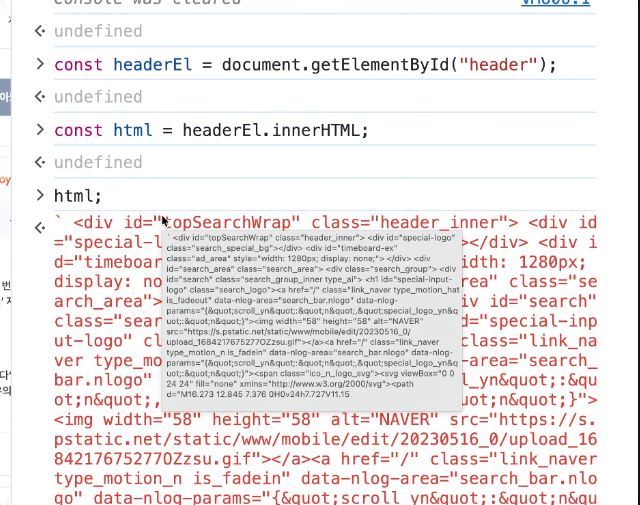
- header안의 html 문자열을 가져옴
- 실시간성 o: 변경시 바로 값이 바뀜
  - 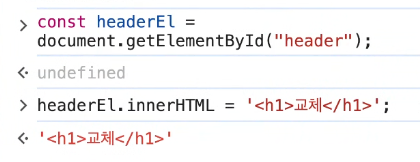
  - 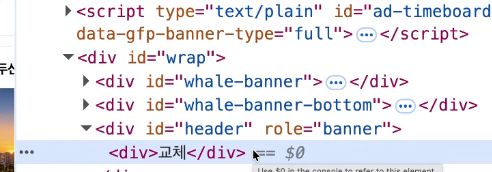
  - 값 바뀜 확인

innerText
- 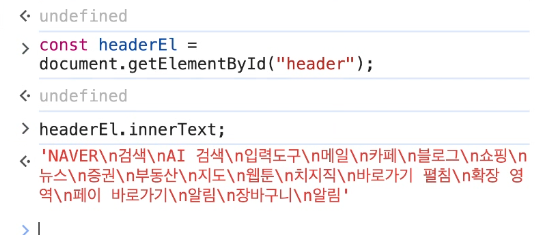
- 실시간성 o

Event
- 웹 페이지 내에서 발생하는 모든 사용자의 행동
- 비동기는 이벤트 기반(다른작업중에 이벤트 들어오면 처리)

Event Handler
- 이벤트가 발생했을 때 실행되는 함수

1. `setTimeout(이벤트핸들러, 지연시간);`: 지연 실행 
   - 1000초 = 1초
   - 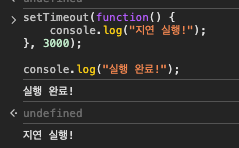
   - 이벤트 핸들러 등록 번호 반환
     - 등록번호: 등록된 이벤트 핸들러 취소시 사용 `clearTimeout(등록번호)`
     - 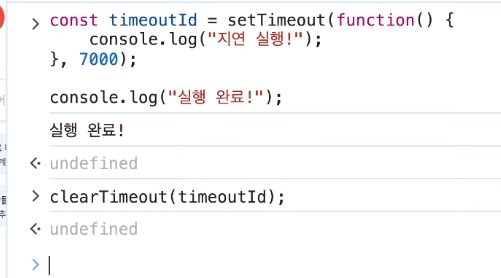



- call stack - task queue / event loop - background 과정
   - 이벤트 여러번 발생시 대기열(task queue)에 넣어놨다가 순서대로 실행 (script는 보조역할이므로 메모리 공간이 한정적임)
   - 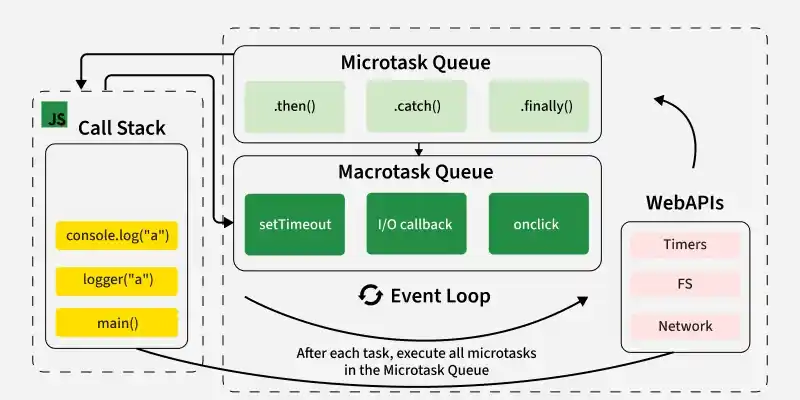


2. `setInterval(이벤트핸들러, 지연시간)`: 지연 시간만큼 반복 실행
   - `clearInterval()`

thread: 작업 단위
- call stack에 위치
- 실행 영역 함수
- 메모리 차지
- JS: single-thread model 비동기형태로 작업을 받아서 동시에 실행할 수 있도록 함.
  - 지연 발생 가능성
  - io 작업 가능하나 cpu 많이 쓰는 무거운 작업들에 한계
  - 많은 요청을 적은 메모리로 처리 가능


JavaScript executes code within a single-threaded environment, which means it can only process one operation at a time.

Despite this limitation, JavaScript can handle asynchronous operations efficiently through its Event Loop mechanism.

event 등록 방법
1. HTML 요소 이벤트 속성
   - `on eventname ...`
   - 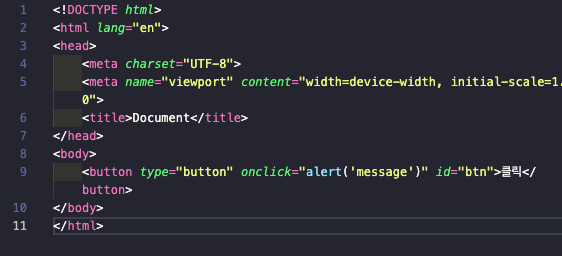
     - 위처럼 태그 안에 함수 작성 지양 (태그 안에 있어 코드가 많으면 찾기 힘듬) -> script 분리해서 사용
   - console.dir()로 onclick 이벤트에 등록된 이벤트핸들러 함수 확인 가능 - 함수가 속성값으로 정의됨
   - 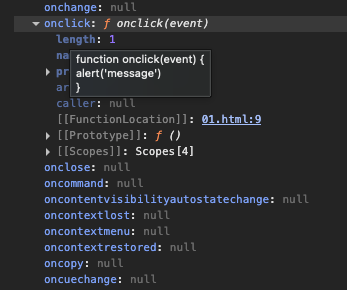
   - 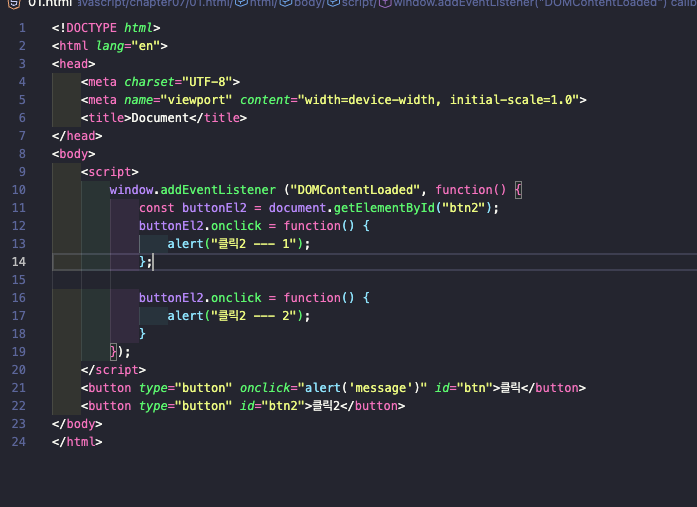
     - 이벤트 하나만 동작(클릭2---2만 alert) 이유: 속성에 바로 대입하므로 주소값이 두번째 alert로 대체되어버림.
     - 1.js, 2.js 파일에서 `window.onload` 사용 예시 -> window.onload사용시 2.js의 함수만 실행됨
2. `document.addEventListener(이벤트명, 이벤트핸들러함수, 캡쳐링여부)`
- 참고: `console.dir(document);`로 event property 확인 가능
- 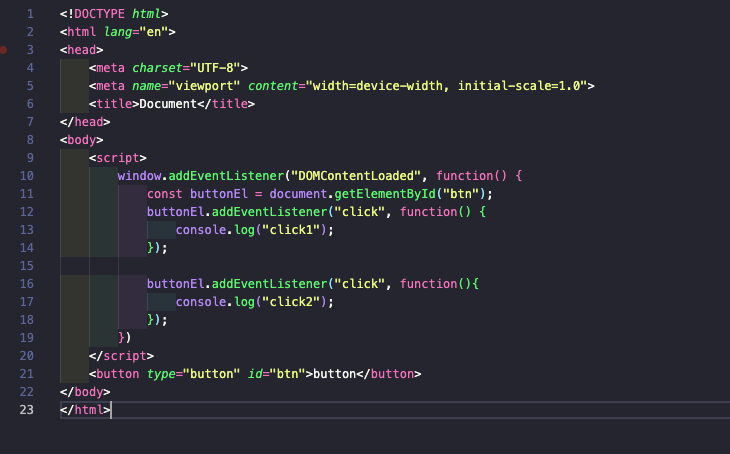
  - 클릭시 2개의 콘솔 정상적으로 출력
    - 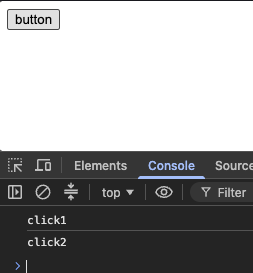
  - 이벤트 전파: 캡쳐링 단계(DOM tree 위->아래 읽기), 버블링 단계
    - 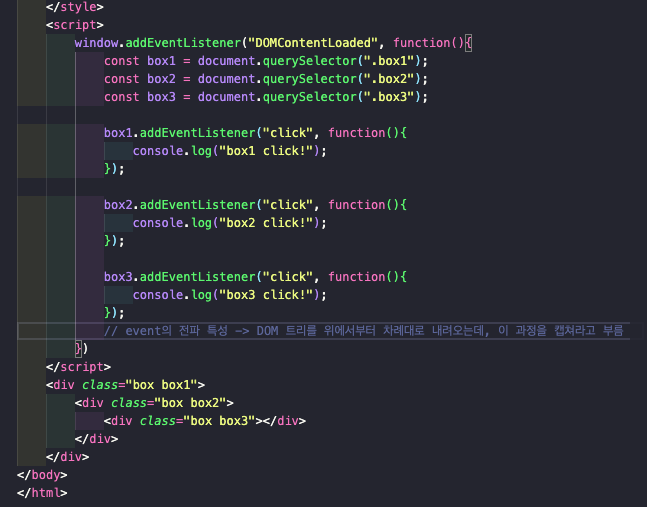
    - box3 클릭시 캡쳐링 단계를 통해 타겟 단계를 찾고, 이벤트 핸들러가 실행됨.
    - 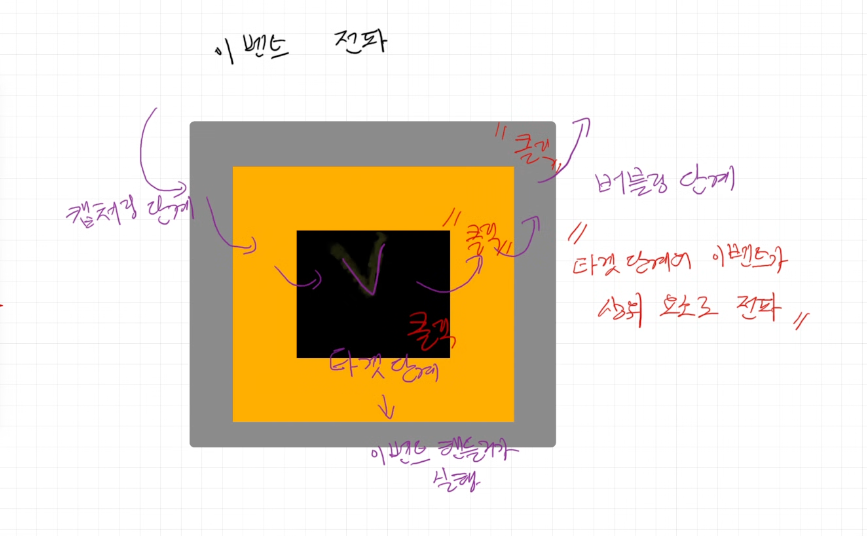
    - 캡쳐링 여부: 이벤트 전파 방향
      - false: 버블링단계에서 전파(기본값)
      - true: 캡쳐링단계에서 전파

```javascript
1. 캡처링 Capturing
window
  ↓
document
  ↓
body
  ↓
box1
  ↓
box2
  ↓

2. 타겟 Target
box3 ← 실제 클릭한 곳

3. 버블링 Bubbling
box3

// 이벤트 전파:
// 캡처링: 부모 → 자식 방향으로 이벤트가 내려감
// 타겟: 실제 이벤트가 발생한 요소에 도착
// 버블링: 타겟 → 부모 방향으로 이벤트가 다시 올라감
```

이벤트 객체: 이벤트 핸들러의 첫번째 매개변수

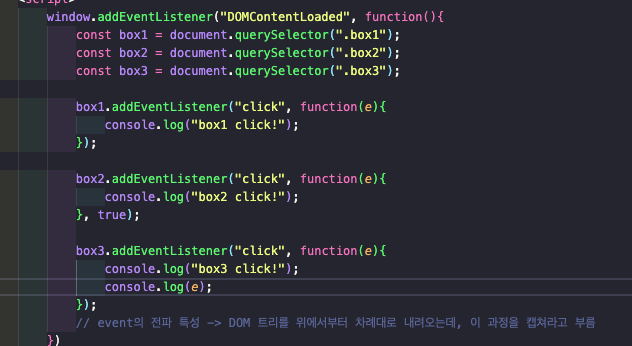
- function(e)의 e: 클릭이 실제로 발생했을 때 브라우저가 함수에 넣어주는 이벤트 객체(Event object)
- 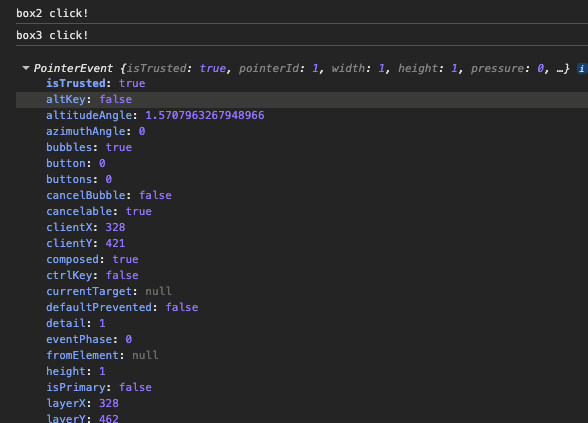
- 콘솔 확인시 이벤트객체 속성 확인 가능
1. 발생한 이벤트와 관련된 정보
2. 이벤트 통제 메서드
    - `.stopPropagation()`: 이벤트 전파 차단
    - ex)
    - 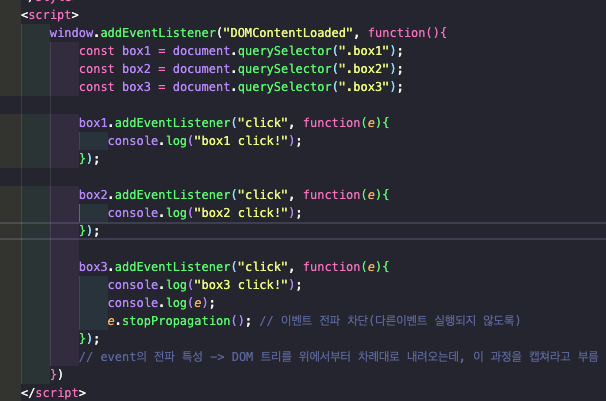
    - 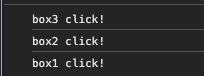
      - box 클릭시마다 하나씩 콘솔 출력 확인
    - `.stopImmediatePropagation()`: 같은 요소의 다른 이벤트도 차단시킴
    - `.preventDefault`

3. 
- `e.currentTarget`: this와 동일한 대상 참조 / 이벤트가 바인딩된 요소
- `e.target`: 실제 이벤트가 발생한 요소


mouse event
- click
- dblclick
- mousemove
- mousedown: 마우스클릭
- mouseup: 마우스클릭 뗄 때
- scroll

keyboard event
- keydown: keypress보다 많이 사용
- keypress: Alt, Ctrl 등 기능키에서 동작 X
- keyup - 키를 누르고 뗄 때

기타
- change event
  - select
  - number
  - range
  - `<input type="file">`
    - fileList

- subint

- focus

- blur

keycode => 유니코드 //엔터키 - B//

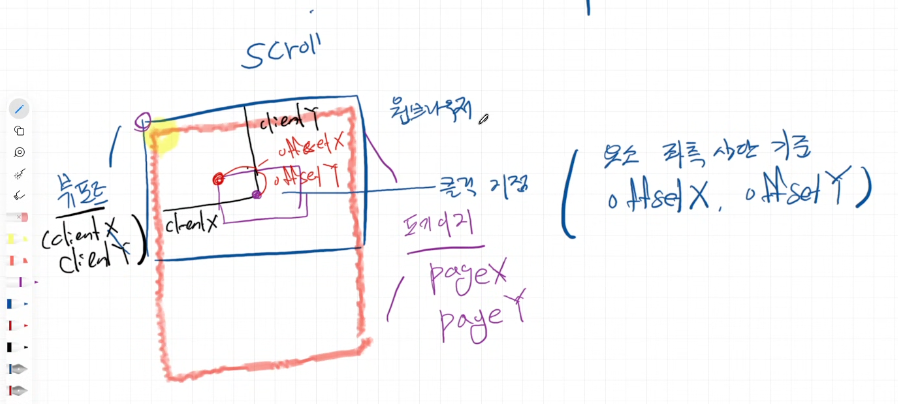

offsetX, offsetY: 이벤트가 발생한 타깃 요소의 왼쪽 위 모서리를 기준으로 마우스 포인터의 X축, Y축 위치를 나타내는 값

```html
<!--04.html-->
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Document</title>
</head>
<body>
    <script>
        window.addEventListener("DOMContentLoaded", function() {
            const el = document.querySelector("a");
            el.addEventListener("click", function(e) {
                e.preventDefault();
                alert("default action prevented!");
                console.log("this:", this); // this를 이용해서 발생한 이벤트 접근 가능, <a> tag 출력
            }) 
        })
    </script>
    <a href="https://naver.com">네이버로 이동</a>
</body>
</html>
```

```html
<!--05.html-->
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Document</title>
</head>
<body>
    <style>
        div {
            background-color: aquamarine;
            block-size: auto;
        }
    </style>
    <script>
        window.addEventListener("DOMContentLoaded", function() {
            const divEl = document.querySelector("div");
            divEl.addEventListener("click", function(e) {
                console.log("this:", this); // this = divEl. event listener가 붙어 있는 요소를 가리킴
                console.log("currentTarget:", e.currentTarget);
                console.log("target", e.target);
            })
        })
    </script>
    <div>
        <span>click</span>
    </div>
</body>
</html>
```

```html
<!--06.html-->

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Document</title>
</head>
<body>
    <script>
        window.addEventListener("DOMContentLoaded", function() {
            const fileEl = document.getElementById("file");
            fileEl.addEventListener("change", function(e) {
                file = e.target.files[0];
                const reader = new FileReader();
                reader.readAsDataURL(file);
                reader.onload = function() {
                    console.log(reader.result);
                    document.getElementById("show-image").innerHTML = `<img src= '${reader.result}' width=300>`
                }
            })
        });
    </script>
    <input type="file" accept="image/*" id="file">
    <div id="show-image"></div>
</body>
</html>
```


output:
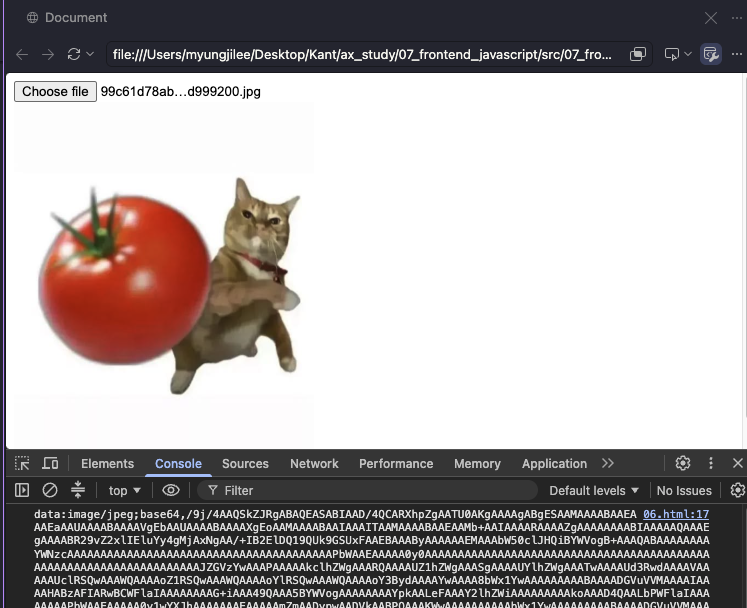
